=== App Usage Summary ===
 Total Walks  Unique Users  Avg Duration (min)  Avg Distance (km)  Avg Rating
        1000           198               29.82               3.05        3.06

=== Top 5 Active Users ===
 user_id  walk_count
user_190          13
 user_99          13
user_161          11
user_113          11
 user_90          10


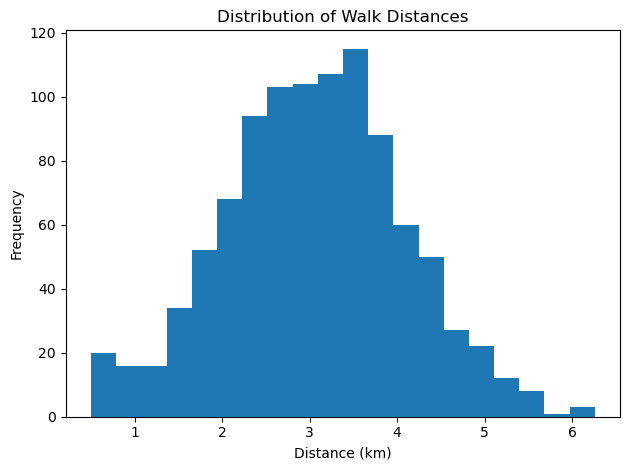

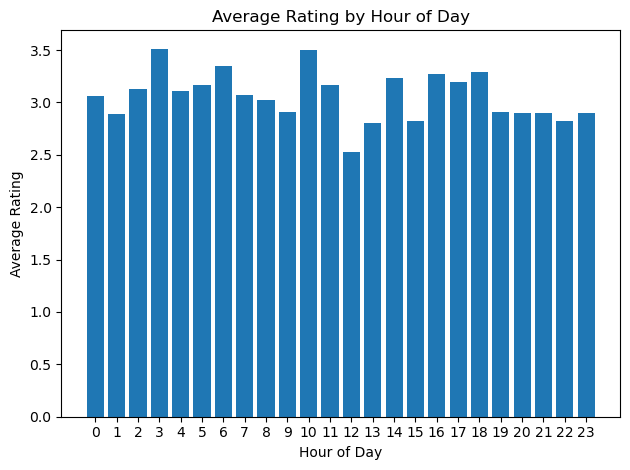

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import random

# 1. Generate synthetic dog‐walking app data
np.random.seed(42)
num_records = 1000
user_ids = [f"user_{i}" for i in range(1, 201)]  # 200 distinct users

data = {
    "user_id": np.random.choice(user_ids, num_records),
    "walk_id": [f"walk_{i}" for i in range(1, num_records + 1)],
    "start_time": [
        datetime.now() - timedelta(
            days=random.randint(0, 30),
            hours=random.randint(0, 23),
            minutes=random.randint(0, 59)
        )
        for _ in range(num_records)
    ],
    "duration_min": np.random.normal(loc=30, scale=10, size=num_records).astype(int).clip(min=5),
    "distance_km": np.random.normal(loc=3, scale=1, size=num_records).clip(min=0.5),
    "rating": np.random.randint(1, 6, size=num_records)
}

df = pd.DataFrame(data)
df["end_time"] = df["start_time"] + pd.to_timedelta(df["duration_min"], unit="m")
df["hour_of_day"] = df["start_time"].dt.hour

# 2. Summary statistics
summary = {
    "Total Walks": len(df),
    "Unique Users": df["user_id"].nunique(),
    "Avg Duration (min)": round(df["duration_min"].mean(), 2),
    "Avg Distance (km)": round(df["distance_km"].mean(), 2),
    "Avg Rating": round(df["rating"].mean(), 2)
}
summary_df = pd.DataFrame([summary])
print("=== App Usage Summary ===")
print(summary_df.to_string(index=False))

# 3. Top 5 most active users
top_users = df["user_id"].value_counts().head(5).reset_index()
top_users.columns = ["user_id", "walk_count"]
print("\n=== Top 5 Active Users ===")
print(top_users.to_string(index=False))

# 4. Plot distribution of walk distances
plt.figure()
plt.hist(df["distance_km"], bins=20)
plt.title("Distribution of Walk Distances")
plt.xlabel("Distance (km)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 5. Plot average rating by hour of day
avg_rating_by_hour = df.groupby("hour_of_day")["rating"].mean().reset_index()
plt.figure()
plt.bar(avg_rating_by_hour["hour_of_day"], avg_rating_by_hour["rating"])
plt.title("Average Rating by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rating")
plt.xticks(avg_rating_by_hour["hour_of_day"])
plt.tight_layout()
plt.show()
